# CNN 課堂練習：MNIST 手寫數字分類 (作業要求請以簡報說明為主！！！)

請在下方各 Part 的程式碼 Cell 自行完成實作。範例模板不提供可直接執行的解答；請保留每一項指定輸出。

## 繳交規範

1. 依 Part 1 至 Part 5 的順序完成。
2. MNIST 必須由程式自動下載並載入，資料路徑須使用相對路徑。
3. 執行結果請保留在 Notebook 中。
4. 繳交前執行 **Restart Kernel and Run All**，確認所有 Cell 可由上至下執行。
5. 檔名請改為 `[學號]CNN課堂練習.ipynb`。


## 共用設定與套件匯入

請匯入本作業所需套件，並設定 random seed、device、batch size 與資料儲存的相對路徑。後續 Part 若使用這些變數，請確保本 Cell 可先正常執行。


In [1]:
# 隨機抽取圖片用
import random
from pathlib import Path
import torch
# 提供 CNN 需要的卷積層、全連接層等模型元件
from torch import nn
# DataLoader 會把資料分批；random_split 用來切出驗證集
from torch.utils.data import DataLoader, random_split
# datasets 用來下載及讀取 MNIST；transforms 用來轉換與正規化圖片
from torchvision import datasets, transforms
# plt 用來顯示手寫數字圖片，以及之後的訓練曲線
import matplotlib.pyplot as plt

SEED = 42 # 固定隨機起點，讓資料切分等隨機操作較容易重現
BATCH_SIZE = 64 # 模型每批的讀取圖片數量，分批以控制記憶體用量

DATA_DIR = Path("data_MNIST")

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

# 設定 Python 與 PyTorch 的隨機起點
random.seed(SEED)
torch.manual_seed(SEED)

# Part 1. Data Preparation（15 分）

## 作業要求

1. 自動下載並載入 MNIST Dataset。
2. 將影像轉換為模型可使用的資料格式，並完成必要的資料型態轉換與 Normalize。
3. 將原始 Training Set 劃分為 Training Set 與 Validation Set；原始 Test Set 僅作為 Test Set。
4. 建立 Training、Validation、Test 所需的 mini-batch DataLoader。

## 必須輸出

- Training、Validation、Test 的資料數量。
- 一個 training batch 的 image shape 與 label shape。
- 5 張 MNIST 圖片及其 Ground Truth Label。


Training 數量: 54000
Validation 數量: 6000
Test 數量: 10000
一個 batch 的 image shape: (64, 1, 28, 28)
一個 batch 的 label shape: (64,)
標籤資料型態: torch.int64


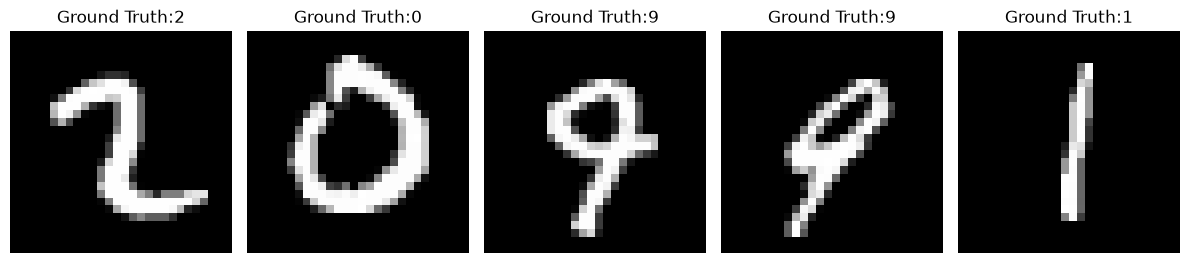

In [2]:
# 定義每張 MNIST 圖片讀入後要做的處理。
image_transform = transforms.Compose([
    # 將圖片轉成 PyTorch tensor，並把像素值從 0～255 縮放到 0～1
    transforms.ToTensor(),

    # MNIST 是單通道灰階圖片，所以平均值和標準差各填一個數
    # 這裡再把像素值調整到約 -1～1，完成 Normalize
    transforms.Normalize((0.5,), (0.5,))
])

# 讀取 MNIST 原始訓練集；本機沒有資料時會自動下載到 DATA_DIR
full_train = datasets.MNIST(
    root=DATA_DIR,
    train=True,
    download=True,
    transform=image_transform
)

# 讀取 MNIST 原始測試集
test_dataset = datasets.MNIST(
    root=DATA_DIR,
    train=False,
    download=True,
    transform=image_transform
)

# 作業沒有指定切分比例；這裡選 90% 訓練、10% 驗證
validation_size = int(len(full_train) * 0.1)
train_size = int(len(full_train) * 0.9)

# random_split 會隨機分組，且兩組不會包含同一筆資料
# 使用固定 SEED，重新執行 Notebook 時會得到相同的切分
train_dataset, validation_dataset = random_split(
    full_train,
    [train_size, validation_size],
    generator=torch.Generator().manual_seed(SEED)
)

print("Training 數量:", len(train_dataset))
print("Validation 數量:", len(validation_dataset))
print("Test 數量:", len(test_dataset))

# DataLoader 會把資料集分成一批一批，供模型依序讀取
# 訓練資料打亂順序，避免每個 epoch 都以相同順序看到圖片
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

# 驗證與測試只用來評估，不需要打亂順序。
validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# 從訓練資料讀取第一個 batch，檢查圖片和標籤的形狀
batch_images, batch_labels = next(iter(train_loader))

print("一個 batch 的 image shape:", tuple(batch_images.shape))
print("一個 batch 的 label shape:", tuple(batch_labels.shape))
print("標籤資料型態:", batch_labels.dtype)

# 建立一排 5 個小圖，準備顯示同一個 batch 的前 5 張圖片
fig, axes = plt.subplots(1, 5, figsize=(12, 3))

for index, ax in enumerate(axes):
    # 圖片先前經過 Normalize；這裡為了正常顯示，把像素轉回 0～1
    # squeeze(0) 會移除大小為 1 的「通道」維度，留下 28×28 圖片
    display_image = batch_images[index].squeeze(0) * 0.5 + 0.5
    ax.imshow(display_image, cmap="grey", vmin=0, vmax=1)
    ax.set_title(f"Ground Truth:{batch_labels[index].item()}")
    ax.axis("off")

plt.tight_layout()
plt.show()


# Part 2. CNN Model（20 分）

## 作業要求

請使用 PyTorch 或 Keras 自行設計 CNN。模型至少須包含：

- 至少一層 2D Convolution Layer。
- Non-linear Activation Function，例如 ReLU。
- 至少一層 Pooling Layer。
- Fully Connected Layer。
- 最終輸出 10 個類別。

## 必須輸出

- 完整模型架構。
- 每一層的 Layer Name 與 Output Shape。


In [3]:
# Sequential 會讓圖片依照下面列出的順序通過每一層
model = nn.Sequential(
    # 輸入是 1 通道灰階圖；卷積後產生 32 個特徵通道
    # padding=1 讓 3×3 卷積後的圖片仍是 28×28
    nn.Conv2d(1, 32, kernel_size=3, padding=1),
    nn.ReLU(), # 加入非線性，讓模型能學習較複雜的特徵
    nn.MaxPool2d(2), # 寬、高各減半：28×28 → 14×14

    nn.Conv2d(32, 64, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2), # 14×14 → 7×7

    nn.Flatten(), # 每張圖的 64×7×7 個數值攤平成一列
    nn.Linear(64 * 7 * 7, 128),
    nn.ReLU(),
    nn.Linear(128, 10) # 產生對數字 0～9 的 10 個分類分數（分數越高的數字就是模型選擇的值）
).to(device) # 把模型放到前面選定的 mps 裝置

print(model)

# 從 training loader 取出一個 batch；這裡只需要圖片，不需要標籤
sample_images, _ = next(iter(train_loader))

# 只取第一張圖片，並搬到模型使用的運算裝置(mps)
x = sample_images[:1].to(device)
print("輸入圖片:", tuple(x.shape))

# 逐層執行模型，查看每一層處理後的資料形狀
# no_grad 表示這次只是檢查，不需要記錄訓練用的梯度
with torch.no_grad():
    for i, layer in enumerate(model):
        x = layer(x)
        print(f"第 {i + 1} 層 {layer.__class__.__name__}: {tuple(x.shape)}")

Sequential(
  (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (4): ReLU()
  (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (6): Flatten(start_dim=1, end_dim=-1)
  (7): Linear(in_features=3136, out_features=128, bias=True)
  (8): ReLU()
  (9): Linear(in_features=128, out_features=10, bias=True)
)
輸入圖片: (1, 1, 28, 28)
第 1 層 Conv2d: (1, 32, 28, 28)
第 2 層 ReLU: (1, 32, 28, 28)
第 3 層 MaxPool2d: (1, 32, 14, 14)
第 4 層 Conv2d: (1, 64, 14, 14)
第 5 層 ReLU: (1, 64, 14, 14)
第 6 層 MaxPool2d: (1, 64, 7, 7)
第 7 層 Flatten: (1, 3136)
第 8 層 Linear: (1, 128)
第 9 層 ReLU: (1, 128)
第 10 層 Linear: (1, 10)


# Part 3. CNN Training（30 分）

## 作業要求

完成 CNN 的訓練流程，至少包括：

1. Forward Propagation。
2. Loss Calculation。
3. Backward Propagation。
4. Parameter Update。

請使用適合 multi-class classification 的 loss function，以及任一合適的 optimizer，例如 SGD 或 Adam。至少訓練 **10 epochs**，並依 Validation 表現保留最佳模型。

## 必須輸出

每個 epoch 均須輸出：

- Training Loss
- Training Accuracy
- Validation Loss
- Validation Accuracy


In [4]:
# 至少訓練 10 輪；一輪代表看過整個 training dataset 一次
EPOCHS = 10

# 訓練過程中，會把 validation 表現最好的模型存到這個相對路徑
BEST_MODEL_PATH = Path("best_mnist_cnn.pt")

# 比較模型輸出的 10 個分數與正確標籤，算出 loss
criterion = nn.CrossEntropyLoss()

# Adam 會根據梯度調整模型參數；lr 是每次調整的學習率
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

history = {
    "train_loss": [],
    "train_accuracy": [],
    "validation_loss": [],
    "validation_accuracy": [],
}
 
best_validation_accuracy = float("-inf") # 負無限大開始，確保第一個 epoch 的 accuracy 會成為目前最佳值

for epoch in range(EPOCHS):
    # Training
    model.train() # 切到訓練模式
    train_loss_sum = 0.0
    train_correct = 0

    for images, labels in train_loader:
        # 把圖片和正確標籤搬到與模型相同的裝置
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad() # 清除上一個 batch 留下的梯度
        logits = model(images) # Forward：讓模型產生 10 個分數
        loss = criterion(logits, labels) # 比較預測與正確答案
        loss.backward() # Backward：計算各參數的梯度
        optimizer.step() # Update：依梯度更新模型參數

        # 累計這個 batch 的 loss 和答對數量
        train_loss_sum += loss.item() * images.size(0)
        train_correct += (logits.argmax(dim=1) == labels).sum().item()
    
    train_loss = train_loss_sum / len(train_dataset)
    train_accuracy = train_correct /len(train_dataset)

    # Validation
    model.eval() # 切到驗證模式
    validation_loss_sum = 0.0
    validation_correct = 0

    # Validation 只檢查表現，不更新模型，因此不需要記錄梯度
    with torch.no_grad():
        for images, labels in validation_loader:
            images = images.to(device)
            labels = labels.to(device)

            logits = model(images)
            loss = criterion(logits, labels)

            validation_loss_sum += loss.item() * images.size(0)
            validation_correct += (logits.argmax(dim=1) == labels).sum().item()
    
    validation_loss = validation_loss_sum / len(validation_dataset)
    validation_accuracy = validation_correct / len(validation_dataset)

    # 儲存該輪結果，供後續畫圖
    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_accuracy)
    history["validation_loss"].append(validation_loss)
    history["validation_accuracy"].append(validation_accuracy)

    # 只有 validation accuracy 創下新高，才覆寫最佳模型檔案
    if validation_accuracy > best_validation_accuracy:
        best_validation_accuracy = validation_accuracy
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        saved_note = " <- 已儲存最佳模型"
    else:
        saved_note = ""


    print(
        f"Epoch {epoch + 1:02d}/{EPOCHS} | "
        f"Train loss: {train_loss:.4f}, accuracy: {train_accuracy:.2%} | "
        f"Validation loss: {validation_loss:.4f}, accuracy: {validation_accuracy:.2%}"
        f"{saved_note}"
    )
    

Epoch 01/10 | Train loss: 0.1745, accuracy: 94.89% | Validation loss: 0.0683, accuracy: 98.00% <- 已儲存最佳模型
Epoch 02/10 | Train loss: 0.0478, accuracy: 98.53% | Validation loss: 0.0684, accuracy: 97.92%
Epoch 03/10 | Train loss: 0.0314, accuracy: 99.01% | Validation loss: 0.0445, accuracy: 98.87% <- 已儲存最佳模型
Epoch 04/10 | Train loss: 0.0240, accuracy: 99.26% | Validation loss: 0.0413, accuracy: 98.83%
Epoch 05/10 | Train loss: 0.0173, accuracy: 99.46% | Validation loss: 0.0454, accuracy: 98.68%
Epoch 06/10 | Train loss: 0.0148, accuracy: 99.49% | Validation loss: 0.0391, accuracy: 98.93% <- 已儲存最佳模型
Epoch 07/10 | Train loss: 0.0117, accuracy: 99.62% | Validation loss: 0.0392, accuracy: 99.02% <- 已儲存最佳模型
Epoch 08/10 | Train loss: 0.0094, accuracy: 99.68% | Validation loss: 0.0460, accuracy: 98.87%
Epoch 09/10 | Train loss: 0.0091, accuracy: 99.69% | Validation loss: 0.0404, accuracy: 99.13% <- 已儲存最佳模型
Epoch 10/10 | Train loss: 0.0073, accuracy: 99.76% | Validation loss: 0.0414, accuracy: 99

# Part 4. Training Curve（15 分）

## 作業要求

根據 Part 3 記錄的訓練結果，繪製模型的學習曲線。

## 必須輸出

1. **Loss Curve**：包含 Training Loss 與 Validation Loss，x-axis 為 Epoch，y-axis 為 Loss。
2. **Accuracy Curve**：包含 Training Accuracy 與 Validation Accuracy，x-axis 為 Epoch，y-axis 為 Accuracy。

共需輸出 **2 張圖、4 條曲線**。


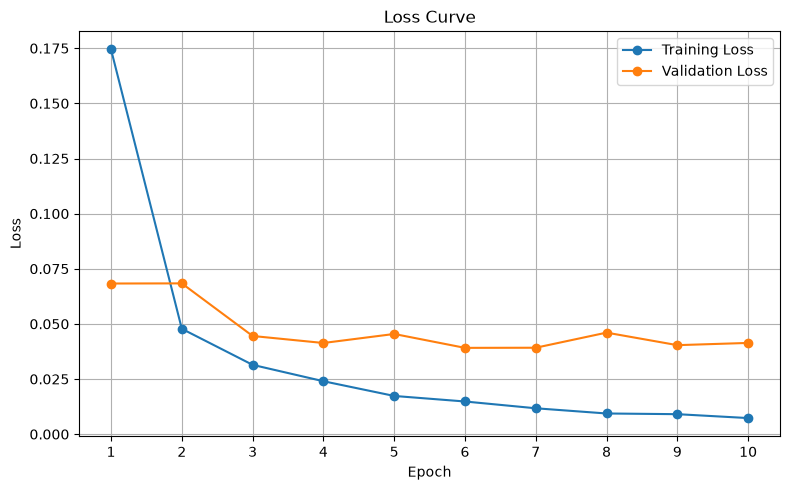

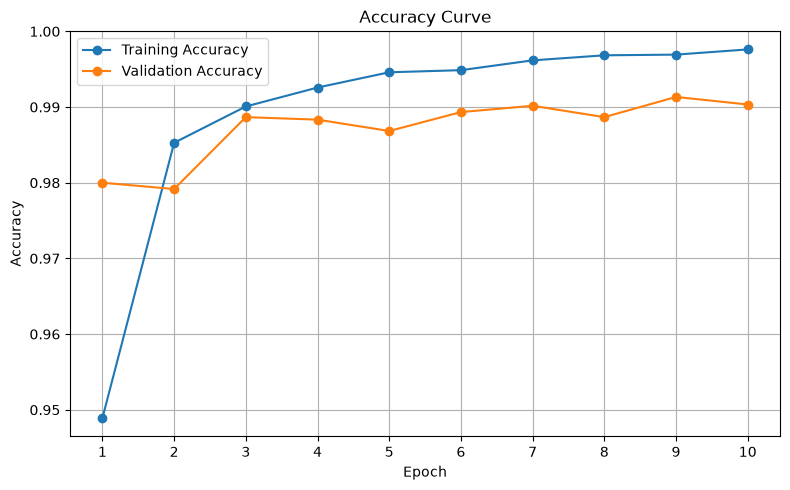

In [5]:
# history 裡每個清單都記錄了每一輪的結果
# 如果記錄了 10 輪，epoch_numbers 就是 [1, 2, ..., 10]
epoch_numbers = list(range(1, len(history["train_loss"]) + 1))

# 第一張圖：Loss Curve
plt.figure(figsize=(8, 5))

plt.plot(epoch_numbers, history["train_loss"], marker="o", label="Training Loss")
plt.plot(epoch_numbers, history["validation_loss"], marker="o", label="Validation Loss")

plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(epoch_numbers)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# 第二張圖：Accuracy Curve
plt.figure(figsize=(8, 5))

plt.plot(epoch_numbers, history["train_accuracy"], marker="o", label="Training Accuracy")
plt.plot(epoch_numbers, history["validation_accuracy"], marker="o", label="Validation Accuracy")

plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.xticks(epoch_numbers)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Part 5. Test Evaluation（10 分）

## 作業要求

1. 載入 Part 3 在 Validation 階段選出的最佳模型。
2. 使用完整 Test Set 進行最終測試。
3. 計算整體及各類別的評估結果。
4. 使用模型對 Test Set 圖片進行 prediction。

## 必須輸出

- 整體 Test Accuracy。
- 數字 0 至 9 各類別 Accuracy。
- 隨機 5 張 Test MNIST 圖片；每張均須顯示 Ground Truth Label 與 Predict Label。


Overall Test Accuracy: 99.07%
Digit 0: 99.69% (977/980)
Digit 1: 99.47% (1129/1135)
Digit 2: 99.61% (1028/1032)
Digit 3: 99.41% (1004/1010)
Digit 4: 99.49% (977/982)
Digit 5: 99.22% (885/892)
Digit 6: 98.85% (947/958)
Digit 7: 97.96% (1007/1028)
Digit 8: 99.69% (971/974)
Digit 9: 97.32% (982/1009)


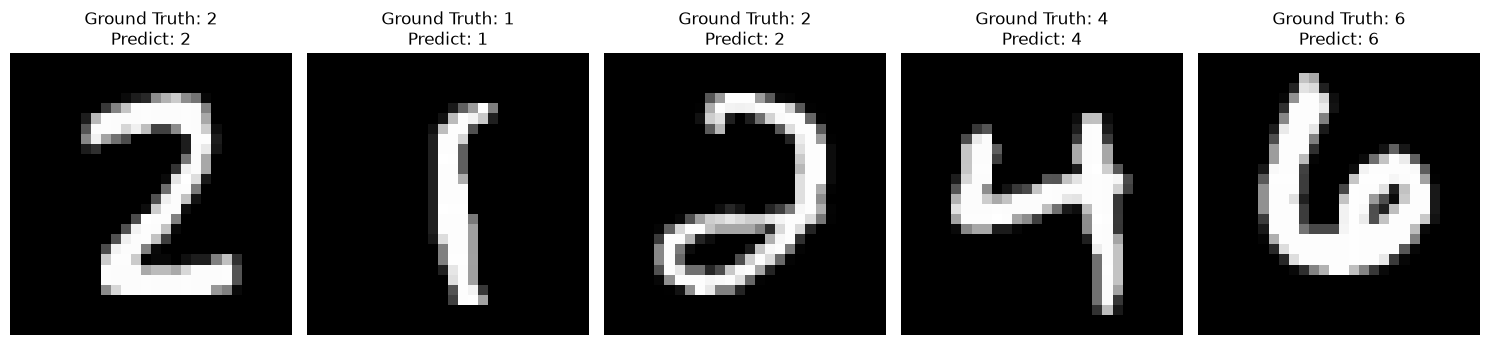

In [6]:
# 載入最佳模型參數
model.load_state_dict(
    torch.load(BEST_MODEL_PATH, map_location=device, weights_only=True)
)

model.eval() # 切到驗證模式

total_correct = 0
class_correct = [0] * 10 # 分別記錄數字 0～9 各答對幾張
class_total = [0] * 10 # 分別記錄數字 0～9 各有幾張

# Test 只用來驗證，不算梯度也不更新模型
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        logits = model(images)
        predictions = logits.argmax(dim=1)

        # 累計全部答對張數
        total_correct += (predictions == labels).sum().item()

        # 分別累計每個數字的總張數與答對張數
        for digit in range(10):
            is_this_digit = labels == digit
            class_total[digit] += is_this_digit.sum().item()
            class_correct[digit] += ((predictions == labels) & is_this_digit).sum().item()

print(f"Overall Test Accuracy: {total_correct / len(test_dataset):.2%}")

sample_images = random.sample(range(len(test_dataset)), 5)
for digit in range(10):
    accuracy = class_correct[digit] / class_total[digit]
    print(f"Digit {digit}: {accuracy:.2%} ({class_correct[digit]}/{class_total[digit]})")

# 建立隨機的五張圖
fig, axes = plt.subplots(1, 5, figsize=(15, 3.5))
model.eval()

with torch.no_grad():
    for ax, index in zip(axes, sample_images):
        # 依索引取出一張測試圖片及其正確標籤
        image, ground_truth = test_dataset[index]

        # 模型需要 batch 維度；unsqueeze(0) 把 (1, 28, 28)
        # 變成 (1, 1, 28, 28)，也就是「一批包含一張圖片」
        model_input = image.unsqueeze(0).to(device)
        logits = model(model_input)
        prediction = logits.argmax(dim=1).item()

        # 圖片先前被 Normalize 到約 -1～1；顯示前轉回 0～1
        display_image = image.squeeze(0) * 0.5 + 0.5
        ax.imshow(display_image, cmap="grey", vmin=0, vmax=1)
        ax.set_title(f"Ground Truth: {ground_truth}\nPredict: {prediction}")
        ax.axis("off")

plt.tight_layout()
plt.show()